In [ ]:
import sys
sys.path.append("../../src/")
from common_imports import *
from numpy import linalg as la
import kibble_zurek as kz
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)


In [2]:
def g(t,tau,alpha=1):
    """
    Time Dependent g(t) with a potential nonlinearity in quench speed controlled by alpha.
    """
    return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
#Time Evolution

In [3]:

def BdG_Evolution(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(t,tau,alpha))@U
def BdG_stationary_evolve(t,U,q,g):
    return -1j*BdG(q,g)@U       

What do I want my code to do :

Quench from initial to final with g = 1-t/tau

hold at final for time 

In [4]:

def evolve_mode(q, t0, tau, t_eval,t_eval_hold,alpha=1):
    V0 = la.eigh(BdG(q, g(t0, tau,alpha)))[1][:, 1]
    sol = solve_ivp(
        BdG_Evolution,
        [t_eval[0], t_eval[-1]],
        V0,
        args=(tau, q,alpha),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05
    )
    V1 = array([sol.y[0][-1],sol.y[1][-1]],dtype=complex)
    #print(g(t_eval[-1],tau,alpha))
    sol2= solve_ivp(
        BdG_stationary_evolve,
        [t_eval_hold[0],t_eval_hold[-1]],
        V1,
        args =(q,g(t_eval[-1],tau,alpha)),
        t_eval=t_eval_hold,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05
    )

    u = np.concatenate( (sol.y[0] , sol2.y[0]) )
    v = np.concatenate( (sol.y[1] , sol2.y[1]) )
    return u,v


def landau_states(tau, L,g0,gf,hold_time,alpha=1,):
    N_timesteps = 500
    
    t0=(1-g0)*tau
    tf=(1-gf)*tau
    t_eval = np.linspace(t0, tf, N_timesteps)
    t_eval_hold = np.linspace(tf,tf+hold_time,N_timesteps)
    t_plot = np.concatenate( (t_eval, t_eval_hold) ) 



    n = np.arange(0, L // 2)
    k = (2 * n + 1) * pi / L
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, t0, tau, t_eval,t_eval_hold,alpha) for q in k
    )

    us, vs = map(np.array, zip(*results))
    states = [[us[:, i], vs[:, i], k] for i in range(len(t_plot))]
    return states, t_plot


In [5]:
def GroundStateOverlap(states):
    overlaps = []
    u0,v0,_ = states[0]
    for ui,vi,_ in states:
        overlaps.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi))**2)
    return array(overlaps)


In [6]:
colors = ["blue","red","green"]

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


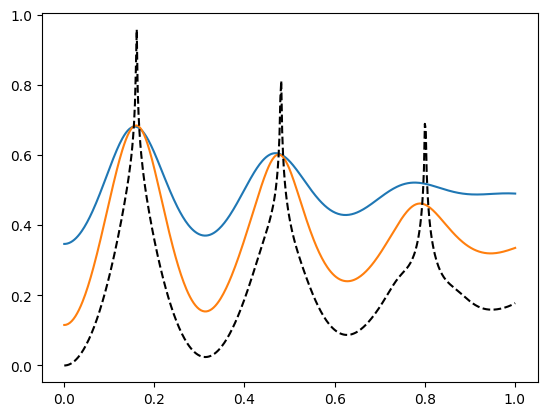

In [7]:
g0= 0
gf= -5
tau = 0.0001
L = 16
states,t= landau_states(tau,L,g0,gf,1)
ns= [2,6]
for n in ns:
    test_dat = [-log(kz.P_n(n,s))/n for s in states]

    plot(t,test_dat)

plot(t,-log(GroundStateOverlap(states))/L,"--k")

In [174]:
L = 100
tau = .0000001

ts = (-1*tau,tau)
gf = 1- ( ts[1]/tau)
print(1-(ts[0]/tau))
print(gf)
states,t = landau_states(tau,L,ts=ts)
ns = [2,4,8]
for c,n in zip(colors,ns):
    print(n)
    datx = array([1/2-(kz.P_n(n,s)) for s in states])
    plot(np.arange(len(t))[len(t)//2+1:],(datx)[len(t)//2+1:],label=f"Sudden Quench n={n}",ls="-.",color=c)
#plot(np.arange(len(t)),(GroundStateOverlap(states)) ,"--k")
legend()
tau = 5
ts = (-1*tau,tau)

states,t = landau_states(tau,L,ts=ts)
for c,n in zip(colors,ns):
   datx = array([1/2-(kz.P_n(n,s)) for s in states])
   plot(np.arange(len(t)),(datx),label=f"Slow Quench n={n}",color=c)
   plt.hlines((n-1)/4/pi/sqrt(2*tau),0,10000,color="black",ls="-.")
#plot(np.arange(len(t)),(GroundStateOverlap(states)) ,color="black")
plt.vlines(len(t)/2,0,1,color="black")
title(rf"Ground State Defects; $\tau = $ {tau}, $g_f = $ {gf}")
xlim(len(t)//2,len(t))
yscale("log")
legend()

2.0
0.0


TypeError: landau_states() got an unexpected keyword argument 'ts'

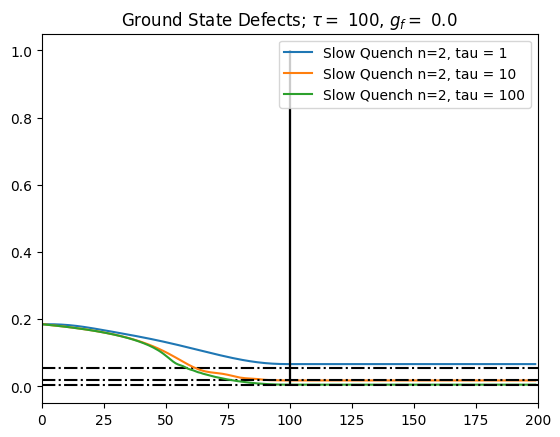

In [163]:
L=100
taus = [1,10,100]
tauf=  100
ts2= (-1*tauf,tauf)


for tau in taus:
  ts = (-1*tau,tau)

  states,t = landau_states(tau,L,ts=ts)
  for c,n in zip(colors,ns):
    datx = array([1/2-(kz.P_n(n,s)) for s in states])
    plot(np.arange(len(t)),abs((datx)),label=f"Slow Quench n={n}, tau = {tau}")
    plt.hlines((n-1)/4/pi/sqrt(2*tau),0,10000,color="black",ls="-.")
  #plot(np.arange(len(t)),(GroundStateOverlap(states)) ,color="black")
  plt.vlines(len(t)/2,0,1,color="black")
  title(rf"Ground State Defects; $\tau = $ {tau}, $g_f = $ {gf}")
  xlim(0,len(t))
  #yscale("log")
legend()